In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn import preprocessing
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
df = pd.read_csv("dataset\\Iris.csv")

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


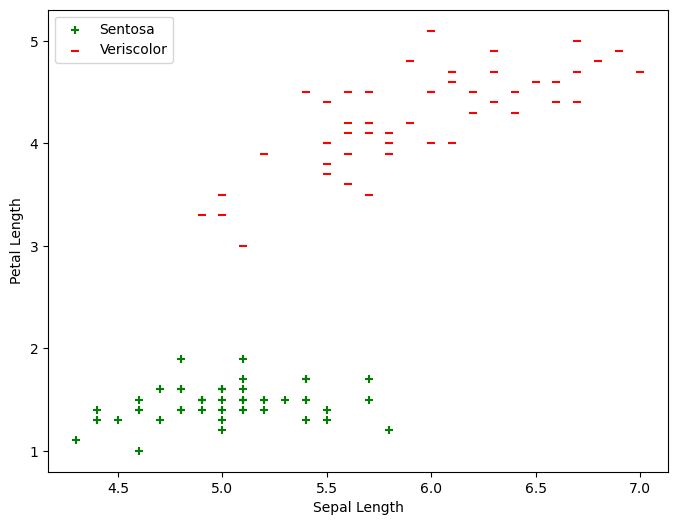

In [7]:
# Get sepal length and petal length data
x = df['SepalLengthCm']
y = df['PetalLengthCm']

# Get sepal length and petal length data of sentosa

setosa_x = df[df['Species'] == 'Iris-setosa']['SepalLengthCm']

setosa_y = df[df['Species'] == 'Iris-setosa']['PetalLengthCm']

# Get sepal length and petal length data of versicolor

versicolor_x =  df[df['Species'] == 'Iris-versicolor']['SepalLengthCm']

versicolor_y =  df[df['Species'] == 'Iris-versicolor']['PetalLengthCm']

# Plot a scatter between SepalLengthCm and PetalLengthCm of sentosa and verisicolor

plt.figure(figsize=(8,6))

plt.scatter(setosa_x,setosa_y, marker='+', color='green', label = "Sentosa")

plt.scatter(versicolor_x,versicolor_y, marker='_', color='red', label = "Veriscolor")

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()
plt.show()

In [9]:
#Extract target label Species and encode using LabelEncoder
from sklearn.preprocessing import LabelEncoder
sample_data = df["Species"]

encoder = LabelEncoder()

encoder.fit(sample_data)

Y = df["Species"]

Y = encoder.transform(sample_data)


#drop Id and Species column

df = df.drop(["Id", "Species"], axis=1)
X = df

print(X.shape)
print(Y.shape)

(150, 4)
(150,)


In [11]:
## Split data by 80x20 using traing_test_split function

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state=42)

print(X.shape)
print(y.shape)

print(X_train.shape)
print(X_test.shape)

(150, 4)
(150,)
(127, 4)
(23, 4)


In [13]:
#Create SVM model and train
y_train = y_train.astype(int)

mexercise = SVC(kernel='linear', C=0.1)
mexercise.fit(X_train, y_train)  # Train the model

SVC(C=0.1, kernel='linear')

In [15]:
#Predict with test data

y_pred = mexercise.predict(X_test)

In [17]:
y_test = y_test.astype(int)
cm = confusion_matrix(y_test, y_pred)

print(cm)

clr = classification_report(y_test, y_pred)

print(clr)

[[8 0 0 0 0]
 [0 0 3 0 0]
 [0 0 7 0 0]
 [0 0 0 4 0]
 [0 0 0 0 1]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           3       0.00      0.00      0.00         3
           4       0.70      1.00      0.82         7
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         1

    accuracy                           0.87        23
   macro avg       0.74      0.80      0.76        23
weighted avg       0.78      0.87      0.82        23



C:\Users\darre\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darre\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darre\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


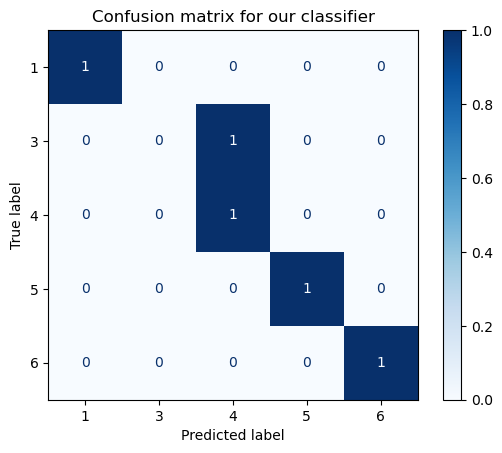

In [21]:
matrix = ConfusionMatrixDisplay.from_estimator(mexercise, X_test, y_test, cmap=plt.cm.Blues, normalize='true')


plt.title('Confusion matrix for our classifier')
plt.show(matrix)
plt.show()